# İmporting Libraries

In [1]:
import os
import glob
from sklearn.utils import shuffle
from sklearn.model_selection import GroupShuffleSplit
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#config
BATCH_SIZE = 32
#LEARNING_RATE = ..
IMAGE_SIZE = 224
SEQUENCE_LENGTH = 16

### Train-Test-Val Split

In [ ]:
from facenet_pytorch import MTCNN
import torch
import cv2
from pathlib import Path

import cv2
from pathlib import Path
device = torch.device('cuda')

# OpenCV'nin dahili yüz dedektörü
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def crop_largest_face(frame, margin=0.2):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))
    
    if len(faces) == 0:
        return None
    
    # En büyük yüzü al
    largest = max(faces, key=lambda f: f[2] * f[3])
    x, y, w, h = largest
    
    # Margin
    x1 = max(0, int(x - w * margin))
    y1 = max(0, int(y - h * margin))
    x2 = min(frame.shape[1], int(x + w * (1 + 2 * margin)))
    y2 = min(frame.shape[0], int(y + h * (1 + 2 * margin)))
    
    return frame[y1:y2, x1:x2]

def process_videos(input_folder, output_folder, fps_sample=1):
    Path(output_folder).mkdir(parents=True, exist_ok=True)
    videos = list(Path(input_folder).glob("*.mp4"))
    print(f"Toplam {len(videos)} video bulundu")
    
    for i, video_path in enumerate(videos):
        cap = cv2.VideoCapture(str(video_path))
        fps = cap.get(cv2.CAP_PROP_FPS)
        interval = max(1, int(fps * fps_sample))
        
        out_path = Path(output_folder) / video_path.name
        writer = None
        frame_idx = 0
        saved = 0
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            if frame_idx % interval == 0:
                face = crop_largest_face(frame)
                if face is not None:
                    face_resized = cv2.resize(face, (224, 224))
                    if writer is None:
                        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
                        writer = cv2.VideoWriter(
                            str(out_path), fourcc,
                            fps / interval, (224, 224)
                        )
                    writer.write(face_resized)
                    saved += 1
            
            frame_idx += 1
        
        cap.release()
        if writer:
            writer.release()
        
        if (i+1) % 50 == 0:
            print(f"[{i+1}/{len(videos)}] tamamlandı")

process_videos(
    input_folder="/kaggle/input/datasets/puneeth5727/faceforensic/Forensicface++/original",
    output_folder="/kaggle/working/ff_cropped_real"
)

In [2]:
#### import random
random.seed(42)
np.random.seed(42)

BASE = '/kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2/FakeAVCeleb_v1.2'

# 1. Dosyaları topla
fake1 = glob.glob(f'{BASE}/FakeVideo-FakeAudio/**/*.mp4', recursive=True)
fake2 = glob.glob(f'{BASE}/FakeVideo-RealAudio/**/*.mp4', recursive=True)
real_files = glob.glob(f'{BASE}/RealVideo-RealAudio/**/*.mp4', recursive=True)

ff_real_files = glob.glob('/kaggle/working/ff_cropped_real/*.mp4')
real_files = real_files + ff_real_files

print(f"Fake1 (FakeAudio): {len(fake1)}")
print(f"Fake2 (RealAudio): {len(fake2)}")
print(f"Real:              {len(real_files)}")

# 2. ID'leri çek — PREFIX OLMADAN, kişi bazlı split için
fake1_ids = [yol.split('/')[-2] for yol in fake1]
fake2_ids = [yol.split('/')[-2] for yol in fake2]
real_ids = []
for yol in real_files:
    if 'ff_cropped_real' in yol:
        # Alt klasör olmadığı için dosya adını (uzantısız) ID olarak atıyoruz
        # Örn: '001.mp4' -> 'ff_001'
        kisi_id = yol.split('/')[-1].split('.')[0]
        real_ids.append(f"ff_{kisi_id}")
    else:
        # FakeAVCeleb formatı (alt klasör var)
        real_ids.append(yol.split('/')[-2])
        
fake_files = fake1 + fake2 
fake_labels = [1] * len(fake_files)
fake_ids = fake1_ids + fake2_ids

real_labels = [0] * len(real_files)

all_files  = np.array(fake_files + real_files)
all_labels = np.array(fake_labels + real_labels)
all_ids    = np.array(fake_ids + real_ids)

# 3. KİŞİ BAZLI SPLIT — undersampling'den ÖNCE
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, temp_idx = next(gss.split(all_files, groups=all_ids))

temp_files  = all_files[temp_idx]
temp_labels = all_labels[temp_idx]
temp_ids    = all_ids[temp_idx]

gss_val = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=42)
val_idx, test_idx = next(gss_val.split(temp_files, groups=temp_ids))

train_files  = all_files[train_idx]
train_labels = all_labels[train_idx]
val_files    = temp_files[val_idx]
val_labels   = temp_labels[val_idx]
test_files   = temp_files[test_idx]
test_labels  = temp_labels[test_idx]

# 4. OVERLAP KONTROLÜ — ikisi de 0 çıkmalı
train_persons = set(all_ids[train_idx])
val_persons   = set(temp_ids[val_idx])
test_persons  = set(temp_ids[test_idx])
print(f"\nTrain-Test ortak kişi: {len(train_persons & test_persons)}")
print(f"Train-Val ortak kişi:  {len(train_persons & val_persons)}")

# 5. TRAIN UNDERSAMPLİNG — her iki fake klasöründen dengeli seç
train_files  = np.array(train_files)
train_labels = np.array(train_labels)

# Train setindeki fake1 ve fake2 dosyalarını ayrıştır
train_fake1_idx = np.array([i for i, f in enumerate(train_files) 
                             if f in set(fake1) and train_labels[i] == 1])
train_fake2_idx = np.array([i for i, f in enumerate(train_files) 
                             if f in set(fake2) and train_labels[i] == 1])
train_real_idx  = np.where(train_labels == 0)[0]

n_each = 6000  
selected_fake1 = np.random.choice(train_fake1_idx, 
                                   min(n_each, len(train_fake1_idx)), 
                                   replace=False)
selected_fake2 = np.random.choice(train_fake2_idx, 
                                   min(n_each, len(train_fake2_idx)), 
                                   replace=False)

final_train_idx = np.concatenate([selected_fake1, selected_fake2, train_real_idx])
np.random.shuffle(final_train_idx)

train_files  = train_files[final_train_idx]
train_labels = train_labels[final_train_idx]

# 6. VAL UNDERSAMPLİNG — dengeli tut
val_files  = np.array(val_files)
val_labels = np.array(val_labels)

val_fake_idx = np.where(val_labels == 1)[0]
val_real_idx = np.where(val_labels == 0)[0]

n_val_fake = min(len(val_real_idx) * 2, len(val_fake_idx))
selected_val_fake = np.random.choice(val_fake_idx, n_val_fake, replace=False)

final_val_idx = np.concatenate([selected_val_fake, val_real_idx])
np.random.shuffle(final_val_idx)

val_files  = val_files[final_val_idx]
val_labels = val_labels[final_val_idx]

# 7. ÖZET
print(f"\nTrain: {np.sum(train_labels==1)} Fake | {np.sum(train_labels==0)} Real")
print(f"Val:   {np.sum(val_labels==1)} Fake | {np.sum(val_labels==0)} Real")
print(f"Test:  {np.sum(test_labels==1)} Fake | {np.sum(test_labels==0)} Real")

# Train'de fake1/fake2 dağılımı — dengeli mi kontrol et
train_fake1_final = sum(1 for f in train_files if f in set(fake1))
train_fake2_final = sum(1 for f in train_files if f in set(fake2))
print(f"\nTrain Fake1 (FakeAudio): {train_fake1_final}")
print(f"Train Fake2 (RealAudio): {train_fake2_final}")

Fake1 (FakeAudio): 10851
Fake2 (RealAudio): 9709
Real:              1500

Train-Test ortak kişi: 0
Train-Val ortak kişi:  0

Train: 12000 Fake | 1200 Real
Val:   300 Fake | 150 Real
Test:  2115 Fake | 150 Real

Train Fake1 (FakeAudio): 6000
Train Fake2 (RealAudio): 6000


## Generator

In [3]:
import cv2
from torch.utils.data import Dataset
from PIL import Image

class DataGenerator(Dataset):
    def __init__(self, paths: list, labels: list, sequence_length: int = 10, IMAGE_SIZE: int = 224, 
                 transform=None, augment_temporal: bool = False):
        self.paths = paths
        self.labels = labels
        self.sequence_length = sequence_length
        self.transform = transform
        self.augment_temporal = augment_temporal
        self.IMAGE_SIZE = IMAGE_SIZE

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        video_path = self.paths[idx]
        label = self.labels[idx]
        
        # Kareleri çek
        frames = self._load_video(video_path)
        
        # Transform (Resize, Normalize, ToTensor vb.)
        if self.transform:
            # transform genellikle tek bir görsel bekler, o yüzden her kareye uyguluyoruz
            frames = [self.transform(frame) for frame in frames]
        
        # Kareleri birleştir (Stack) -> (Sequence, Channels, Height, Width)
        # Örn: (10, 3, 299, 299)
        frames_tensor = torch.stack(frames)
        
        # Etiketi tensor yap
        label_tensor = torch.tensor(label, dtype=torch.float32)
        
        return frames_tensor, label_tensor

    def _load_video(self, path, tta_seed=None):
        cap = cv2.VideoCapture(path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames = []

        if total_frames == 0:
            cap.release()
            return [Image.fromarray(
                np.zeros((self.IMAGE_SIZE, self.IMAGE_SIZE, 3), dtype=np.uint8)
            )] * self.sequence_length
    
        if total_frames > self.sequence_length:
            max_start_index = total_frames - self.sequence_length
    
            if self.augment_temporal:
                # Training: tamamen random
                start_frame = random.randint(0, max_start_index) #np.randomda en sondaki sayıyı dahil etmezken randomda dahil ediyor o yüzden +1 yazmadım bunda
            else:
                # Val/Test: seed'li random (TTA için farklı seed geçilebilir)
                rng = np.random.RandomState(seed=tta_seed if tta_seed is not None else 42)
                start_frame = rng.randint(0, max_start_index + 1)
    
            indices = np.arange(start_frame, start_frame + self.sequence_length)
        else:
            indices = np.arange(total_frames)
    
        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
            ret, frame = cap.read()
            if ret:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frame = Image.fromarray(frame)
                frames.append(frame)
            else:
                break
    
        cap.release()
    
        # Padding
        while len(frames) < self.sequence_length:
            if len(frames) > 0:
                frames.append(frames[-1].copy())  # son kareyi tekrarla
            else:
                frames.append(Image.fromarray(
                    np.zeros((self.IMAGE_SIZE, self.IMAGE_SIZE, 3), dtype=np.uint8)
                ))
    
        return frames

In [4]:
from torch.utils.data import DataLoader
from torchvision import transforms

# 1. Gümrük Kapısı (Transform) Tanımlaması
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    # PyTorch'un ImageNet ön-eğitimli modelleri için ZORUNLU standart sapma ve ortalama
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])
# 2. Dataset'lerin Oluşturulması (Dosya Yollarını ve Transform'u Bağlıyoruz)
train_dataset = DataGenerator(paths=train_files, labels=train_labels, sequence_length=SEQUENCE_LENGTH, transform=transform, augment_temporal=True)
val_dataset = DataGenerator(paths=val_files, labels=val_labels, sequence_length=SEQUENCE_LENGTH, transform=transform)
test_dataset = DataGenerator(paths=test_files, labels=test_labels, sequence_length=SEQUENCE_LENGTH, transform=transform)

"""
sample_weights = [41.0 if label == 0 else 1.0 for label in train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(train_labels),
    replacement=True
)


# train_loader'da shuffle=True varsa kaldır, sampler ekle:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,      
    num_workers=2,
    pin_memory=True
)
"""
# 3. DataLoader Kurulumu (Veriyi GPU'ya batch'ler halinde taşıyan asıl kamyonlar)
# Eğitimde model ezberlemesin diye shuffle=True yapıyoruz, Val ve Test'te sırayla okuyoruz.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

In [5]:

test_files  = np.array(test_files)
test_labels = np.array(test_labels)

test_fake_idx = np.where(test_labels == 1)[0]
test_real_idx = np.where(test_labels == 0)[0]

n_test_fake = min(len(test_real_idx) * 2, len(test_fake_idx))
selected_test_fake = np.random.choice(test_fake_idx, n_test_fake, replace=False)

final_test_idx = np.concatenate([selected_test_fake, test_real_idx])
np.random.shuffle(final_test_idx)
test_files  = test_files[final_test_idx]
test_labels = test_labels[final_test_idx]

test_dataset = DataGenerator(paths=test_files, labels=test_labels, sequence_length=SEQUENCE_LENGTH, transform=transform)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


## Training

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm 

import sys
sys.path.append('/kaggle/input/datasets/zuhalaltiner/models')
from deepfake_models2 import build_model

# 1. Cihaz Seçimi (Ekran kartın varsa onu kullanır, yoksa işlemciye geçer)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Eğitim şu cihazda yapılıyor: {device}")

# 2. Modeli Başlatma (İster "lstm" ister "transformer" seç)
model = build_model("efficientnet", sequence_length=SEQUENCE_LENGTH).to(device)

# 3. Dengesiz Veri İçin Özel Loss (Hata) Fonksiyonu
# BCEWithLogitsLoss = Sigmoid + Binary Cross Entropy (Çok daha stabil çalışır)


n_fake_train = np.sum(train_labels == 1)  # 4000
n_real_train = np.sum(train_labels == 0)  # 400

pos_weight_val = n_real_train / n_fake_train  # 400/4000 = 0.1

pos_weight = torch.tensor([pos_weight_val]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"pos_weight: {pos_weight_val:.2f}")  # 0.10 çıkmalı

# 4. Optimizasyon (Öğrenme Algoritması)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# ----------------- EĞİTİM DÖNGÜSÜ -----------------
epochs = 10
best_val_loss = float('inf') 

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}
for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    
    # --- A) EĞİTİM (TRAIN) FAZI ---
    model.train() # Modeli eğitim moduna al (Dropout vb. aktifleşir)
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # train_loader dünkü DataGenerator'ından gelen DataLoader
    progress_bar = tqdm(train_loader, desc="Eğitim")
    for batch_x, batch_y in progress_bar:
        # Verileri GPU/CPU'ya taşı ve boyutları ayarla
        batch_x = batch_x.to(device) 
        batch_y = batch_y.to(device).float().unsqueeze(1) # Çıktı (B, 1) olmalı
        
        # 1. Adım: Eski türevleri sıfırla
        optimizer.zero_grad()
        
        # 2. Adım: İleri Besleme (Tahmin yap)
        outputs = model(batch_x)
        
        # 3. Adım: Hatayı Hesapla
        loss = criterion(outputs, batch_y)
        
        # 4. Adım: Geriye Yayılım (Hataları öğren)
        loss.backward()

        #şuna bir bak neymişşşş
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 5. Adım: Ağırlıkları Güncelle
        optimizer.step()
        
        # İstatistikleri Tut
        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) >= 0.5).float() # %50'den büyükse 1 (Fake)
        correct_train += (preds == batch_y).sum().item()
        total_train += batch_y.size(0)
        
        # Barda anlık loss göster
        progress_bar.set_postfix({'Loss': loss.item()})
        
    train_acc = correct_train / total_train
    
    # --- B) DOĞRULAMA (VALIDATION) FAZI ---
    model.eval() # Modeli test moduna al (Dropout kapanır, kilitler devreye girer)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Gradient hesaplamayı kapat (VRAM ve hız tasarrufu)
        for batch_x, batch_y in tqdm(val_loader, desc="Doğrulama"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).float().unsqueeze(1)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct_val += (preds == batch_y).sum().item()
            total_val += batch_y.size(0)
            
    val_acc = correct_val / total_val
    avg_val_loss = val_loss / len(val_loader)
    
    # Tur Sonu Özeti
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: %{train_acc*100:.2f}")
    print(f"Val Loss:   {val_loss/len(val_loader):.4f} | Val Acc:   %{val_acc*100:.2f}")
    
    history['train_loss'].append(train_loss/len(train_loader))
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    
    if avg_val_loss < best_val_loss:
        print(f"🌟 Val Loss düştü ({best_val_loss:.4f} --> {avg_val_loss:.4f}). Model kaydediliyor...")
        best_val_loss = avg_val_loss
        
        # Sadece ağırlıkları (state_dict) kaydetmek PyTorch'ta en iyi pratiktir.
        torch.save(model.state_dict(), 'best_model_efficientnet.pth')

In [8]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_ismi="Model"):
    # Epoch sayısını buluyoruz (Örn: 10 epoch ise x ekseni 1'den 10'a kadar olacak)
    # Not: history sözlüğündeki anahtar isimleri (train_loss vb.) senin train_and_evaluate 
    # fonksiyonunun içine göre değişiklik gösterebilir, gerekirse burayı düzeltiriz.
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Yan yana 2 tane grafik çizeceğimiz geniş bir tuval açıyoruz
    plt.figure(figsize=(14, 5))
    
    # --- 1. GRAFİK: LOSS (Kayıp) ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Eğitim (Train) Loss', linewidth=2)
    plt.plot(epochs, history['val_loss'], 'r--', label='Doğrulama (Val) Loss', linewidth=2)
    plt.title(f'{model_ismi} - Kayıp (Loss) Grafiği', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # --- 2. GRAFİK: ACCURACY (Doğruluk) ---
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Eğitim (Train) Acc', linewidth=2)
    plt.plot(epochs, history['val_acc'], 'r--', label='Doğrulama (Val) Acc', linewidth=2)
    plt.title(f'{model_ismi} - Doğruluk (Accuracy) Grafiği', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    
    # İndirmek istersen diye resmi kaydediyoruz
    plt.savefig(f"{model_ismi}_egitim_grafikleri.png", dpi=300, bbox_inches='tight')
    plt.show()


In [ ]:
plot_training_history(history, model_ismi="EfficientNet")

In [ ]:
# eğitim sonu
import matplotlib.pyplot as plt

# Figür ve alt grafikler (subplots) oluştur (1 satır, 2 sütun)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Grafik: Kayıp (Loss)
ax1.plot(history['train_loss'], label='Eğitim Loss', color='blue', marker='o')
ax1.plot(history['val_loss'], label='Doğrulama Loss', color='red', marker='o')
ax1.set_title('Model Kaybı (Loss)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# 2. Grafik: Doğruluk (Accuracy)
ax2.plot(history['train_acc'], label='Eğitim Acc', color='blue', marker='o')
ax2.plot(history['val_acc'], label='Doğrulama Acc', color='red', marker='o')
ax2.set_title('Model Doğruluğu (Accuracy)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("⚙️ En iyi model ağırlıkları yükleniyor...")
# 6. Epoch'ta kaydedilen en iyi modeli yüklüyoruz
model.load_state_dict(torch.load('best_model_efficientnet.pth'))

# Modeli değerlendirme (test) moduna alıyoruz (Dropout vb. kapanır)
model.eval()

test_loss = 0.0
correct_test = 0
total_test = 0

# Tahminleri ve gerçek değerleri tutacağımız listeler
all_preds = []
all_labels = []

print("🚀 Test verileri üzerinde değerlendirme başlıyor...")

with torch.no_grad(): # Gradient hesaplamayı kapat (VRAM ve hız tasarrufu)
    for batch_x, batch_y in tqdm(test_loader, desc="Test Süreci"):
        # Verileri GPU/CPU'ya taşı
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).float().unsqueeze(1)
        
        # Model tahmini
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        test_loss += loss.item()
        
        # Sigmoid ile [0, 1] arasına çek ve 0.5 eşiği ile yuvarla
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        
        correct_test += (preds == batch_y).sum().item()
        total_test += batch_y.size(0)
        
        # CPU'ya alıp numpy dizisine çevirerek listeye ekle
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Ortalama sonuçları hesapla
test_acc = correct_test / total_test
avg_test_loss = test_loss / len(test_loader)

print("\n" + "="*40)
print("🎯 TEST SONUÇLARI")
print("="*40)
print(f"Test Loss (Kayıp): {avg_test_loss:.4f}")
print(f"Test Accuracy (Doğruluk): %{test_acc*100:.2f}")
print("="*40)

# Dengesiz veri setleri için hayati önem taşıyan detaylı metrikler
print("\n📊 DETAYLI SINIFLANDIRMA RAPORU (Classification Report):")
print(classification_report(all_labels, all_preds, target_names=['Real (0)', 'Fake (1)']))

# Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Değer')
plt.title('Test Verisi - Karmaşıklık Matrisi')
plt.show()

In [ ]:
from IPython.display import FileLink
FileLink("best_model_resnext.pth")

## Resnet eğitim

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm 
# Bunu build_model'den ÖNCE çalıştır
import torchvision.models as tv_models
import torch

# Kaggle'da internet kapalıysa weights=None yap, sonra manuel yükle
# Settings > Internet > ON yapman lazım önce
import sys
sys.path.append('/kaggle/input/datasets/zuhalaltiner/models')
from deepfake_models2 import build_model

# 1. Cihaz Seçimi (Ekran kartın varsa onu kullanır, yoksa işlemciye geçer)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Eğitim şu cihazda yapılıyor: {device}")

# 2. Modeli Başlatma (İster "lstm" ister "transformer" seç)
model = build_model("resnet", sequence_length=SEQUENCE_LENGTH).to(device)

# 3. Dengesiz Veri İçin Özel Loss (Hata) Fonksiyonu
# BCEWithLogitsLoss = Sigmoid + Binary Cross Entropy (Çok daha stabil çalışır)


n_fake_train = np.sum(train_labels == 1)  # 4000
n_real_train = np.sum(train_labels == 0)  # 400

pos_weight_val = n_real_train / n_fake_train  # 400/4000 = 0.1

pos_weight = torch.tensor([pos_weight_val]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"pos_weight: {pos_weight_val:.2f}")  # 0.10 çıkmalı

# 4. Optimizasyon (Öğrenme Algoritması)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True
)

# Early Stopping parametreleri
early_stop_patience = 5
early_stop_counter = 0

# ----------------- EĞİTİM DÖNGÜSÜ -----------------
epochs = 10
best_val_loss = float('inf') 

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}
for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    
    # --- A) EĞİTİM (TRAIN) FAZI ---
    model.train() # Modeli eğitim moduna al (Dropout vb. aktifleşir)
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # train_loader dünkü DataGenerator'ından gelen DataLoader
    progress_bar = tqdm(train_loader, desc="Eğitim")
    for batch_x, batch_y in progress_bar:
        # Verileri GPU/CPU'ya taşı ve boyutları ayarla
        batch_x = batch_x.to(device) 
        batch_y = batch_y.to(device).float().unsqueeze(1) # Çıktı (B, 1) olmalı
        
        # 1. Adım: Eski türevleri sıfırla
        optimizer.zero_grad()
        
        # 2. Adım: İleri Besleme (Tahmin yap)
        outputs = model(batch_x)
        
        # 3. Adım: Hatayı Hesapla
        loss = criterion(outputs, batch_y)
        
        # 4. Adım: Geriye Yayılım (Hataları öğren)
        loss.backward()

        #şuna bir bak neymişşşş
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 5. Adım: Ağırlıkları Güncelle
        optimizer.step()
        
        # İstatistikleri Tut
        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) >= 0.5).float() # %50'den büyükse 1 (Fake)
        correct_train += (preds == batch_y).sum().item()
        total_train += batch_y.size(0)
        
        # Barda anlık loss göster
        progress_bar.set_postfix({'Loss': loss.item()})
        
    train_acc = correct_train / total_train
    
    # --- B) DOĞRULAMA (VALIDATION) FAZI ---
    model.eval() # Modeli test moduna al (Dropout kapanır, kilitler devreye girer)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Gradient hesaplamayı kapat (VRAM ve hız tasarrufu)
        for batch_x, batch_y in tqdm(val_loader, desc="Doğrulama"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).float().unsqueeze(1)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct_val += (preds == batch_y).sum().item()
            total_val += batch_y.size(0)
            
    val_acc = correct_val / total_val
    avg_val_loss = val_loss / len(val_loader)
    
    # Tur Sonu Özeti
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: %{train_acc*100:.2f}")
    print(f"Val Loss:   {val_loss/len(val_loader):.4f} | Val Acc:   %{val_acc*100:.2f}")
    
    history['train_loss'].append(train_loss/len(train_loader))
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        print(f"🌟 Val Loss düştü ({best_val_loss:.4f} --> {avg_val_loss:.4f}). Model kaydediliyor...")
        best_val_loss = avg_val_loss
        early_stop_counter = 0 
        # Sadece ağırlıkları (state_dict) kaydetmek PyTorch'ta en iyi pratiktir.
        torch.save(model.state_dict(), 'best_model_resnet.pth')
    else:
        early_stop_counter += 1
        print(f"⚠ Val Loss iyileşmedi ({early_stop_counter}/{early_stop_patience})")
        
        if early_stop_counter >= early_stop_patience:
            print("🛑 Early stopping devreye girdi.")
            break

In [ ]:
plot_training_history(history, model_ismi="ResNet")

In [ ]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("⚙️ En iyi model ağırlıkları yükleniyor...")
# 6. Epoch'ta kaydedilen en iyi modeli yüklüyoruz
model.load_state_dict(torch.load('best_model_resnet.pth'))

# Modeli değerlendirme (test) moduna alıyoruz (Dropout vb. kapanır)
model.eval()

test_loss = 0.0
correct_test = 0
total_test = 0

# Tahminleri ve gerçek değerleri tutacağımız listeler
all_preds = []
all_labels = []

print("🚀 Test verileri üzerinde değerlendirme başlıyor...")

with torch.no_grad(): # Gradient hesaplamayı kapat (VRAM ve hız tasarrufu)
    for batch_x, batch_y in tqdm(test_loader, desc="Test Süreci"):
        # Verileri GPU/CPU'ya taşı
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).float().unsqueeze(1)
        
        # Model tahmini
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        test_loss += loss.item()
        
        # Sigmoid ile [0, 1] arasına çek ve 0.5 eşiği ile yuvarla
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        
        correct_test += (preds == batch_y).sum().item()
        total_test += batch_y.size(0)
        
        # CPU'ya alıp numpy dizisine çevirerek listeye ekle
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Ortalama sonuçları hesapla
test_acc = correct_test / total_test
avg_test_loss = test_loss / len(test_loader)

print("\n" + "="*40)
print("🎯 TEST SONUÇLARI")
print("="*40)
print(f"Test Loss (Kayıp): {avg_test_loss:.4f}")
print(f"Test Accuracy (Doğruluk): %{test_acc*100:.2f}")
print("="*40)

# Dengesiz veri setleri için hayati önem taşıyan detaylı metrikler
print("\n📊 DETAYLI SINIFLANDIRMA RAPORU (Classification Report):")
print("ResNet50")
print(classification_report(all_labels, all_preds, target_names=['Real (0)', 'Fake (1)']))

# Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Değer')
plt.title('Test Verisi - Karmaşıklık Matrisi')
plt.show()

## ResNeXt 

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm 

import sys
sys.path.append('/kaggle/input/datasets/zuhalaltiner/models')
from deepfake_models2 import build_model

# 1. Cihaz Seçimi (Ekran kartın varsa onu kullanır, yoksa işlemciye geçer)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Eğitim şu cihazda yapılıyor: {device}")

# 2. Modeli Başlatma (İster "lstm" ister "transformer" seç)
model = build_model("resnext", sequence_length=SEQUENCE_LENGTH).to(device)

# 3. Dengesiz Veri İçin Özel Loss (Hata) Fonksiyonu
# BCEWithLogitsLoss = Sigmoid + Binary Cross Entropy (Çok daha stabil çalışır)


n_fake_train = np.sum(train_labels == 1)  # 4000
n_real_train = np.sum(train_labels == 0)  # 400

pos_weight_val = n_real_train / n_fake_train  # 400/4000 = 0.1

pos_weight = torch.tensor([pos_weight_val]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f"pos_weight: {pos_weight_val:.2f}")  # 0.10 çıkmalı

# 4. Optimizasyon (Öğrenme Algoritması)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

# ----------------- EĞİTİM DÖNGÜSÜ -----------------
epochs = 10
best_val_loss = float('inf') 

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}
for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    
    # --- A) EĞİTİM (TRAIN) FAZI ---
    model.train() # Modeli eğitim moduna al (Dropout vb. aktifleşir)
    train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    # train_loader dünkü DataGenerator'ından gelen DataLoader
    progress_bar = tqdm(train_loader, desc="Eğitim")
    for batch_x, batch_y in progress_bar:
        # Verileri GPU/CPU'ya taşı ve boyutları ayarla
        batch_x = batch_x.to(device) 
        batch_y = batch_y.to(device).float().unsqueeze(1) # Çıktı (B, 1) olmalı
        
        # 1. Adım: Eski türevleri sıfırla
        optimizer.zero_grad()
        
        # 2. Adım: İleri Besleme (Tahmin yap)
        outputs = model(batch_x)
        
        # 3. Adım: Hatayı Hesapla
        loss = criterion(outputs, batch_y)
        
        # 4. Adım: Geriye Yayılım (Hataları öğren)
        loss.backward()

        #şuna bir bak neymişşşş
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 5. Adım: Ağırlıkları Güncelle
        optimizer.step()
        
        # İstatistikleri Tut
        train_loss += loss.item()
        preds = (torch.sigmoid(outputs) >= 0.5).float() # %50'den büyükse 1 (Fake)
        correct_train += (preds == batch_y).sum().item()
        total_train += batch_y.size(0)
        
        # Barda anlık loss göster
        progress_bar.set_postfix({'Loss': loss.item()})
        
    train_acc = correct_train / total_train
    
    # --- B) DOĞRULAMA (VALIDATION) FAZI ---
    model.eval() # Modeli test moduna al (Dropout kapanır, kilitler devreye girer)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # Gradient hesaplamayı kapat (VRAM ve hız tasarrufu)
        for batch_x, batch_y in tqdm(val_loader, desc="Doğrulama"):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device).float().unsqueeze(1)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item()
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct_val += (preds == batch_y).sum().item()
            total_val += batch_y.size(0)
            
    val_acc = correct_val / total_val
    avg_val_loss = val_loss / len(val_loader)
    
    # Tur Sonu Özeti
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: %{train_acc*100:.2f}")
    print(f"Val Loss:   {val_loss/len(val_loader):.4f} | Val Acc:   %{val_acc*100:.2f}")
    
    history['train_loss'].append(train_loss/len(train_loader))
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    
    if avg_val_loss < best_val_loss:
        print(f"🌟 Val Loss düştü ({best_val_loss:.4f} --> {avg_val_loss:.4f}). Model kaydediliyor...")
        best_val_loss = avg_val_loss
        
        # Sadece ağırlıkları (state_dict) kaydetmek PyTorch'ta en iyi pratiktir.
        torch.save(model.state_dict(), 'best_model_resnext.pth')

Eğitim şu cihazda yapılıyor: cuda
Model   : ResNeXt-50     + BiLSTM
CNN dim : 2048
Params  : 29,346,369 total | 20,913,409 trainable
pos_weight: 0.10

--- Epoch 1/10 ---


Doğrulama: 100%|██████████| 15/15 [00:47<00:00,  3.18s/it]


Train Loss: 0.0305 | Train Acc: %95.04
Val Loss:   0.0290 | Val Acc:   %98.67
🌟 Val Loss düştü (inf --> 0.0290). Model kaydediliyor...

--- Epoch 2/10 ---


Doğrulama: 100%|██████████| 15/15 [00:46<00:00,  3.12s/it]


Train Loss: 0.0057 | Train Acc: %99.33
Val Loss:   0.0412 | Val Acc:   %98.67

--- Epoch 3/10 ---


...

Train Loss: 0.0025 | Train Acc: %99.60
Val Loss:   0.0474 | Val Acc:   %98.67

--- Epoch 9/10 ---


Doğrulama: 100%|██████████| 15/15 [00:48<00:00,  3.21s/it]


Train Loss: 0.0033 | Train Acc: %99.64
Val Loss:   0.0120 | Val Acc:   %99.33

--- Epoch 10/10 ---


Doğrulama: 100%|██████████| 15/15 [00:47<00:00,  3.18s/it]

Train Loss: 0.0016 | Train Acc: %99.83
Val Loss:   0.0165 | Val Acc:   %99.33


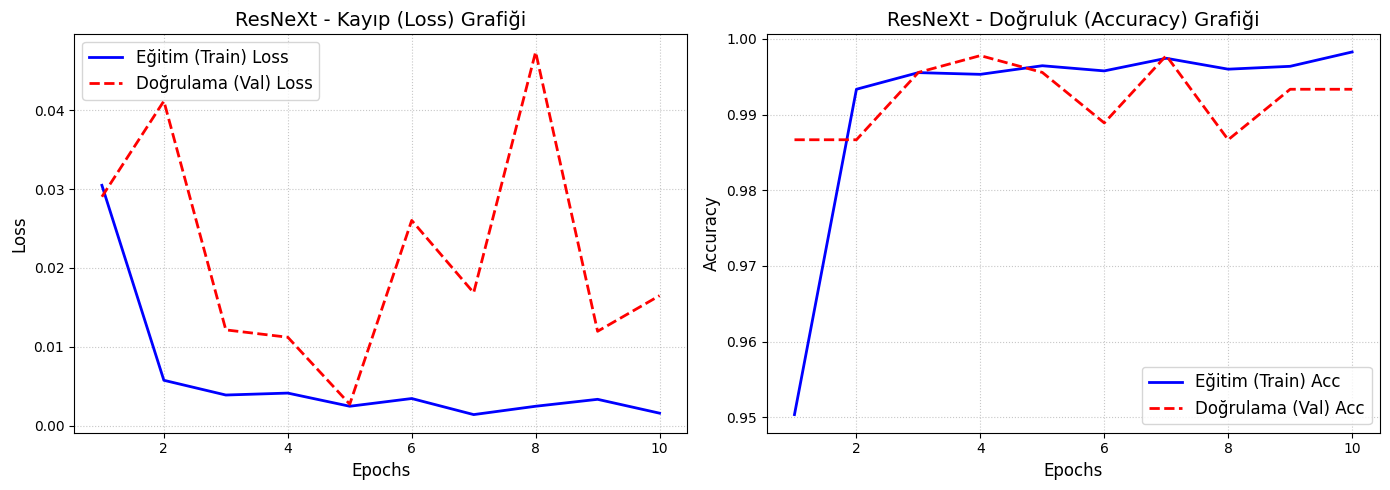

In [9]:
plot_training_history(history, model_ismi="ResNeXt")

/tmp/ipykernel_1174676/2861278107.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model_resnext.pth'))


⚙️ En iyi model ağırlıkları yükleniyor...
🚀 Test verileri üzerinde değerlendirme başlıyor...


Test Süreci: 100%|██████████| 15/15 [00:45<00:00,  3.02s/it]



🎯 TEST SONUÇLARI
Test Loss (Kayıp): 0.0123
Test Accuracy (Doğruluk): %99.78

📊 DETAYLI SINIFLANDIRMA RAPORU (Classification Report):
ResNeXt50
              precision    recall  f1-score   support

    Real (0)       1.00      0.99      1.00       150
    Fake (1)       1.00      1.00      1.00       300

    accuracy                           1.00       450
   macro avg       1.00      1.00      1.00       450
weighted avg       1.00      1.00      1.00       450



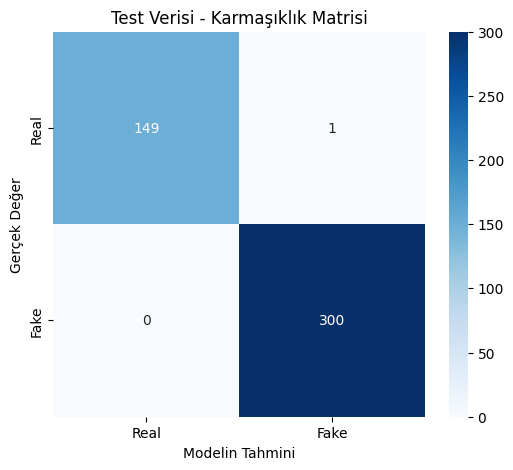

In [10]:
import torch
import numpy as np
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("⚙️ En iyi model ağırlıkları yükleniyor...")
# 6. Epoch'ta kaydedilen en iyi modeli yüklüyoruz
model.load_state_dict(torch.load('best_model_resnext.pth'))

# Modeli değerlendirme (test) moduna alıyoruz (Dropout vb. kapanır)
model.eval()

test_loss = 0.0
correct_test = 0
total_test = 0

# Tahminleri ve gerçek değerleri tutacağımız listeler
all_preds = []
all_labels = []

print("🚀 Test verileri üzerinde değerlendirme başlıyor...")

with torch.no_grad(): # Gradient hesaplamayı kapat (VRAM ve hız tasarrufu)
    for batch_x, batch_y in tqdm(test_loader, desc="Test Süreci"):
        # Verileri GPU/CPU'ya taşı
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).float().unsqueeze(1)
        
        # Model tahmini
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        
        test_loss += loss.item()
        
        # Sigmoid ile [0, 1] arasına çek ve 0.5 eşiği ile yuvarla
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        
        correct_test += (preds == batch_y).sum().item()
        total_test += batch_y.size(0)
        
        # CPU'ya alıp numpy dizisine çevirerek listeye ekle
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# Ortalama sonuçları hesapla
test_acc = correct_test / total_test
avg_test_loss = test_loss / len(test_loader)

print("\n" + "="*40)
print("🎯 TEST SONUÇLARI")
print("="*40)
print(f"Test Loss (Kayıp): {avg_test_loss:.4f}")
print(f"Test Accuracy (Doğruluk): %{test_acc*100:.2f}")
print("="*40)

# Dengesiz veri setleri için hayati önem taşıyan detaylı metrikler
print("\n📊 DETAYLI SINIFLANDIRMA RAPORU (Classification Report):")
print("ResNeXt50")
print(classification_report(all_labels, all_preds, target_names=['Real (0)', 'Fake (1)']))

# Karmaşıklık Matrisi (Confusion Matrix) Görselleştirmesi
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Modelin Tahmini')
plt.ylabel('Gerçek Değer')
plt.title('Test Verisi - Karmaşıklık Matrisi')
plt.show()